# AE-06 and Karim autoencoder comparison

This notebook compares two complete autoencoder methods on the same Bottle data split. Both use the seed-17 80/20 split of the official normal-only training set, and both are evaluated on the same official test set.

The architectures and original preprocessing choices are preserved. AE-06 uses pixels in `[0, 1]` with a sigmoid decoder, while Karim's model uses ImageNet normalization with a tanh decoder. For a fairer training budget, both architectures receive up to 200 epochs with the same learning-rate schedule, and the checkpoint with the lowest normal-validation MSE is retained. Therefore, this is still a comparison of the **complete methods**, not a controlled claim that architecture alone caused a difference.

AUROC is used temporarily because it compares score rankings without requiring a threshold. We still calculate 95th-percentile normal-validation thresholds so the later threshold-based evaluation can use validation data rather than the test set.

In [9]:
from pathlib import Path
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms

from anomaly_detection import MVTecImageDataset, build_mvtec_manifest

SEED = 17
IMAGE_SIZE = 256
BATCH_SIZE = 16
NUM_WORKERS = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = DEVICE.type == 'cuda'
THRESHOLD_PERCENTILE = 95

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
models_dir = project_root / 'models'
models_dir.mkdir(exist_ok=True)
print(f'Using {DEVICE}')

Using cuda


## Shared split

The split is created once and passed to both preprocessing pipelines. The test set is never used for training, checkpoint selection, or threshold calculation.

In [2]:
manifest = build_mvtec_manifest(project_root / 'data/mvtec')
normal_pool = manifest.query(
    "product == 'bottle' and split == 'train' and not is_anomaly"
).reset_index(drop=True)
test_frame = manifest.query(
    "product == 'bottle' and split == 'test'"
).reset_index(drop=True)
train_frame, validation_frame = train_test_split(
    normal_pool, test_size=0.2, random_state=SEED
)
train_frame = train_frame.reset_index(drop=True)
validation_frame = validation_frame.reset_index(drop=True)

assert len(train_frame) == 167 and len(validation_frame) == 42
assert set(train_frame.path).isdisjoint(validation_frame.path)
assert set(normal_pool.path).isdisjoint(test_frame.path)
print(f'Train: {len(train_frame)} normal images')
print(f'Validation: {len(validation_frame)} normal images')
print(f'Test: {len(test_frame)} images ({test_frame.is_anomaly.sum()} anomalous)')

Train: 167 normal images
Validation: 42 normal images
Test: 83 images (63 anomalous)


## Models and original preprocessing

AE-06 is loaded from the checkpoint selected by normal-validation MSE in notebook 03. Karim's original architecture is trained under AE-06's common 200-epoch budget and learning-rate schedule, and the state with the lowest normal-validation MSE is retained. This should be described as **Karim's architecture under the common training protocol**, not as Karim's original 20-epoch experiment.

In [3]:
class ConvAutoencoder16(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, 128, 4, 2, 1), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid(),
        )

    def forward(self, images):
        return self.decoder(self.encoder(images))


class KarimBottleAutoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
        )
        self.flatten = nn.Flatten()
        self.fc_encode = nn.Linear(32 * 32 * 128, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 32 * 32 * 128)
        self.unflatten = nn.Unflatten(1, (128, 32, 32))
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Tanh(),
        )

    def forward(self, images):
        encoded = self.encoder(images)
        latent = self.fc_encode(self.flatten(encoded))
        decoded = self.fc_decode(latent)
        return self.decoder(self.unflatten(decoded))


ae06_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.ToTensor(),
])
karim_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def make_loaders(transform, training_seed):
    train_dataset = MVTecImageDataset(train_frame, transform)
    validation_dataset = MVTecImageDataset(validation_frame, transform)
    test_dataset = MVTecImageDataset(test_frame, transform)
    generator = torch.Generator().manual_seed(training_seed)
    common = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    return (
        DataLoader(train_dataset, BATCH_SIZE, shuffle=True, generator=generator, **common),
        DataLoader(validation_dataset, BATCH_SIZE, shuffle=False, **common),
        DataLoader(test_dataset, BATCH_SIZE, shuffle=False, **common),
    )

ae06_train_loader, ae06_validation_loader, ae06_test_loader = make_loaders(
    ae06_transform, SEED + 6
)
karim_train_loader, karim_validation_loader, karim_test_loader = make_loaders(
    karim_transform, SEED
)

In [6]:
ae06 = ConvAutoencoder16().to(DEVICE)
ae06_checkpoint_path = models_dir / 'ae06_conv_autoencoder16.pt'
ae06_checkpoint = torch.load(ae06_checkpoint_path, map_location=DEVICE, weights_only=False)
assert ae06_checkpoint['metadata']['experiment'] == 'AE-06'
ae06.load_state_dict(ae06_checkpoint['model_state_dict'])
ae06.eval()
print(f"Loaded AE-06 selected at epoch {ae06_checkpoint['metadata']['best_epoch']}")

KARIM_MAX_EPOCHS = 200
KARIM_INITIAL_LEARNING_RATE = 1e-3
KARIM_LR_CHANGE_EPOCH = 150
KARIM_REFINEMENT_LEARNING_RATE = 1e-4
RETRAIN_KARIM = False
karim_checkpoint_path = models_dir / 'karim_architecture_common_protocol.pt'
karim_config = {
    'architecture': 'KarimBottleAutoencoder',
    'latent_dim': 128,
    'seed': SEED,
    'batch_size': BATCH_SIZE,
    'max_epochs': KARIM_MAX_EPOCHS,
    'initial_learning_rate': KARIM_INITIAL_LEARNING_RATE,
    'learning_rate_change_epoch': KARIM_LR_CHANGE_EPOCH,
    'refinement_learning_rate': KARIM_REFINEMENT_LEARNING_RATE,
}
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
karim = KarimBottleAutoencoder(latent_dim=128).to(DEVICE)

if karim_checkpoint_path.exists() and not RETRAIN_KARIM:
    checkpoint = torch.load(karim_checkpoint_path, map_location=DEVICE, weights_only=False)
    if checkpoint.get('metadata', {}).get('config') != karim_config:
        raise ValueError(
            'Karim checkpoint settings differ from the common protocol. '
            'Set RETRAIN_KARIM=True only if replacement is intended.'
        )
    karim.load_state_dict(checkpoint['model_state_dict'])
    karim_history = checkpoint['metadata']['history']
    karim_best_epoch = checkpoint['metadata']['best_epoch']
    print(f'Loaded Karim comparison checkpoint selected at epoch {karim_best_epoch}')
else:
    optimizer = torch.optim.Adam(
        karim.parameters(), lr=KARIM_INITIAL_LEARNING_RATE
    )
    criterion = nn.MSELoss()
    karim_history = {'train_loss': [], 'validation_loss': []}
    best_validation_loss = float('inf')
    best_state = None
    karim_best_epoch = 0
    for epoch in range(1, KARIM_MAX_EPOCHS + 1):
        if epoch == KARIM_LR_CHANGE_EPOCH + 1:
            for parameter_group in optimizer.param_groups:
                parameter_group['lr'] = KARIM_REFINEMENT_LEARNING_RATE
        karim.train()
        train_total = 0.0
        for images, _, _ in karim_train_loader:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            optimizer.zero_grad()
            loss = criterion(karim(images), images)
            loss.backward()
            optimizer.step()
            train_total += loss.item() * len(images)

        karim.eval()
        validation_total = 0.0
        with torch.inference_mode():
            for images, _, _ in karim_validation_loader:
                images = images.to(DEVICE, non_blocking=PIN_MEMORY)
                validation_total += criterion(karim(images), images).item() * len(images)
        train_loss = train_total / len(karim_train_loader.dataset)
        validation_loss = validation_total / len(karim_validation_loader.dataset)
        karim_history['train_loss'].append(train_loss)
        karim_history['validation_loss'].append(validation_loss)
        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            karim_best_epoch = epoch
            best_state = copy.deepcopy(karim.state_dict())
        if epoch == 1 or epoch % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(
                f'Epoch {epoch:03d}: train={train_loss:.6f}, '
                f'validation={validation_loss:.6f}, lr={current_lr:.0e}'
            )

    karim.load_state_dict(best_state)
    torch.save({
        'model_state_dict': karim.state_dict(),
        'metadata': {
            'experiment': 'Karim architecture under common protocol',
            'config': karim_config,
            'best_epoch': karim_best_epoch, 'history': karim_history,
        },
    }, karim_checkpoint_path)
    print(f'Saved {karim_checkpoint_path}')
karim.eval()

Loaded AE-06 selected at epoch 199
Epoch 001: train=2.313928, validation=1.435567, lr=1e-03
Epoch 010: train=0.817420, validation=0.816189, lr=1e-03
Epoch 020: train=0.808104, validation=0.821157, lr=1e-03
Epoch 030: train=0.796731, validation=0.802578, lr=1e-03
Epoch 040: train=0.792603, validation=0.794957, lr=1e-03
Epoch 050: train=0.789747, validation=0.790115, lr=1e-03
Epoch 060: train=0.788234, validation=0.789309, lr=1e-03
Epoch 070: train=0.787412, validation=0.798376, lr=1e-03
Epoch 080: train=0.785843, validation=0.787572, lr=1e-03
Epoch 090: train=0.785342, validation=0.787253, lr=1e-03
Epoch 100: train=0.784761, validation=0.789992, lr=1e-03
Epoch 110: train=0.783896, validation=0.786745, lr=1e-03
Epoch 120: train=0.783504, validation=0.789232, lr=1e-03
Epoch 130: train=0.783084, validation=0.786276, lr=1e-03
Epoch 140: train=0.782422, validation=0.788483, lr=1e-03
Epoch 150: train=0.782736, validation=0.786291, lr=1e-03
Epoch 160: train=0.781903, validation=0.785539, lr=1e

KarimBottleAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc_encode): Linear(in_features=131072, out_features=128, bias=True)
  (fc_decode): Linear(in_features=128, out_features=131072, bias=True)
  (unflatten): Unflatten(dim=1, unflattened_size=(128, 32, 32))
  (decoder): Sequential(
    (0): ConvTranspose2d(12

## Common scoring and evaluation

Each model is scored in three ways. Whole-image MSE averages squared reconstruction error over the complete image. Karim's original Top-1% method selects the largest 1% of individual RGB-channel absolute errors. The spatial Top-1% method first averages the three channel errors at each pixel and then selects the largest 1% of image locations. Keeping both Top-1% definitions makes Karim's original result reproducible while testing the genuinely pixel-level interpretation.

For threshold-based metrics, each model-score combination receives its own threshold calculated as the 95th percentile of its 42 normal-validation scores. The test labels are not used to select or adjust thresholds. Ordinary accuracy is omitted because notebook 01 showed that product-level test sets are imbalanced.

,model,score,validation_threshold_95pct,AUROC,PR_AUC,precision,anomaly_recall,specificity,F1,balanced_accuracy,good_correct,false_alarms,defects_detected,defects_missed
0,AE-06,whole_image_mse,0.000747,0.876984,0.958567,0.924528,0.777778,0.80,0.844828,0.788889,16,4,49,14
1,AE-06,top_1_percent_element_error,0.158280,0.869841,0.957800,0.977778,0.698413,0.95,0.814815,0.824206,19,1,44,19
2,AE-06,top_1_percent_pixel_error,0.141559,0.890476,0.966127,0.976744,0.666667,0.95,0.792453,0.808333,19,1,42,21
3,Karim autoencoder,whole_image_mse,0.800529,0.646825,0.880090,0.875000,0.444444,0.80,0.589474,0.622222,16,4,28,35
4,Karim autoencoder,top_1_percent_element_error,1.648114,0.911508,0.975473,1.000000,0.761905,1.00,0.864865,0.880952,20,0,48,15
5,Karim autoencoder,top_1_percent_pixel_error,1.449573,0.915873,0.976471,1.000000,0.746032,1.00,0.854545,0.873016,20,0,47,16


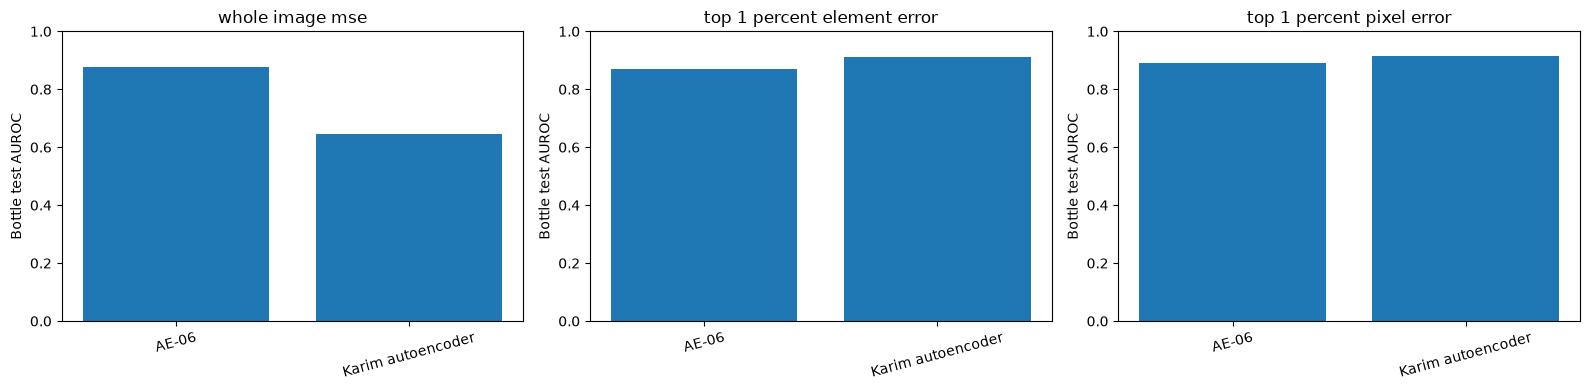

In [10]:
def score_loader(model, loader):
    rows = []
    model.eval()
    with torch.inference_mode():
        for images, labels, paths in loader:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            reconstructions = model(images)
            absolute_errors = (images - reconstructions).abs()
            mse_scores = absolute_errors.square().mean(dim=(1, 2, 3))
            flat_errors = absolute_errors.flatten(start_dim=1)
            k = max(1, int(flat_errors.shape[1] * 0.01))
            top1_scores = torch.topk(flat_errors, k, dim=1).values.mean(dim=1)
            pixel_errors = absolute_errors.mean(dim=1)
            flat_pixel_errors = pixel_errors.flatten(start_dim=1)
            pixel_k = max(1, int(flat_pixel_errors.shape[1] * 0.01))
            top1_pixel_scores = torch.topk(
                flat_pixel_errors, pixel_k, dim=1
            ).values.mean(dim=1)
            rows.extend({
                'label': int(label), 'path': path,
                'whole_image_mse': float(mse),
                'top_1_percent_element_error': float(top1),
                'top_1_percent_pixel_error': float(top1_pixel),
            } for label, path, mse, top1, top1_pixel in zip(
                labels, paths, mse_scores.cpu(), top1_scores.cpu(),
                top1_pixel_scores.cpu(),
            ))
    return pd.DataFrame(rows)

model_specs = {
    'AE-06': (ae06, ae06_validation_loader, ae06_test_loader),
    'Karim autoencoder': (karim, karim_validation_loader, karim_test_loader),
}
score_names = [
    'whole_image_mse',
    'top_1_percent_element_error',
    'top_1_percent_pixel_error',
]
result_rows = []
scored_data = {}
for model_name, (model, validation_loader, test_loader) in model_specs.items():
    validation_results = score_loader(model, validation_loader)
    test_results = score_loader(model, test_loader)
    assert validation_results.label.eq(0).all()
    scored_data[model_name] = (validation_results, test_results)
    for score_name in score_names:
        threshold = np.percentile(
            validation_results[score_name], THRESHOLD_PERCENTILE
        )
        labels = test_results.label.to_numpy()
        predictions = (test_results[score_name] > threshold).astype(int)
        true_negatives = int(((labels == 0) & (predictions == 0)).sum())
        false_positives = int(((labels == 0) & (predictions == 1)).sum())
        true_positives = int(((labels == 1) & (predictions == 1)).sum())
        false_negatives = int(((labels == 1) & (predictions == 0)).sum())
        specificity = true_negatives / (true_negatives + false_positives)
        result_rows.append({
            'model': model_name,
            'score': score_name,
            'validation_threshold_95pct': threshold,
            'AUROC': roc_auc_score(labels, test_results[score_name]),
            'PR_AUC': average_precision_score(labels, test_results[score_name]),
            'precision': precision_score(labels, predictions, zero_division=0),
            'anomaly_recall': recall_score(labels, predictions, zero_division=0),
            'specificity': specificity,
            'F1': f1_score(labels, predictions, zero_division=0),
            'balanced_accuracy': balanced_accuracy_score(labels, predictions),
            'good_correct': true_negatives,
            'false_alarms': false_positives,
            'defects_detected': true_positives,
            'defects_missed': false_negatives,
        })
comparison = pd.DataFrame(result_rows)
display(comparison.round(6))

figure, axes = plt.subplots(1, 3, figsize=(16, 4))
for axis, score_name in zip(axes, score_names):
    subset = comparison.query('score == @score_name')
    axis.bar(subset.model, subset.AUROC)
    axis.set_ylim(0, 1)
    axis.set_ylabel('Bottle test AUROC')
    axis.set_title(score_name.replace('_', ' '))
    axis.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## Results and interpretation

| Model | Scoring method | AUROC | PR-AUC | Precision | Recall | Specificity | F1 | Balanced accuracy | Good correct / false alarms | Defects detected / missed |
| --- | --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| AE-06 | Whole-image MSE | 0.8770 | 0.9586 | 0.9245 | **0.7778** | 0.80 | 0.8448 | 0.7889 | 16 / 4 | **49 / 14** |
| AE-06 | Top-1% element error | 0.8698 | 0.9578 | 0.9778 | 0.6984 | **0.95** | **0.8148** | **0.8242** | **19 / 1** | 44 / 19 |
| AE-06 | Top-1% spatial-pixel error | **0.8905** | **0.9661** | **0.9767** | 0.6667 | **0.95** | 0.7925 | 0.8083 | **19 / 1** | 42 / 21 |
| Karim architecture | Whole-image MSE | 0.6468 | 0.8801 | 0.8750 | 0.4444 | 0.80 | 0.5895 | 0.6222 | 16 / 4 | 28 / 35 |
| Karim architecture | Top-1% element error | 0.9115 | 0.9755 | **1.0000** | **0.7619** | **1.00** | **0.8649** | **0.8810** | **20 / 0** | **48 / 15** |
| Karim architecture | Top-1% spatial-pixel error | **0.9159** | **0.9765** | **1.0000** | 0.7460 | **1.00** | 0.8545 | 0.8730 | **20 / 0** | 47 / 16 |

The two Top-1% variants answer slightly different questions. Karim's spatial-pixel version produced the best ranking performance overall (AUROC 0.9159 and PR-AUC 0.9765). At the frozen 95th-percentile validation threshold, however, Karim's original element-wise version produced the best operating-point result: balanced accuracy 0.8810, F1 0.8649, no false alarms, and 48 of 63 defects detected. It detected one more defect than the spatial-pixel version, which had balanced accuracy 0.8730. The small difference means neither Top-1% definition is universally superior; the spatial version ranks images marginally better, while the original version performed marginally better at this particular validation-derived threshold.

For Karim's architecture, focusing on local high errors was decisive. Whole-image MSE achieved only 0.6468 AUROC and detected 28 of 63 defects. Original element-wise Top-1% scoring increased AUROC by 0.2647 and detected 20 additional defects while eliminating all four false alarms. This supports Karim's hypothesis that anomaly evidence from his model is concentrated in small high-error regions and is diluted by a whole-image average.

For AE-06, the three score rankings were closer. Spatial Top-1% gave its best AUROC (0.8905), but whole-image MSE detected the most defects (49) at the cost of four false alarms. Element-wise Top-1% reduced false alarms to one and achieved AE-06's best balanced accuracy (0.8242), but detected five fewer defects than MSE. This is a recall-specificity trade-off rather than evidence of a single best AE-06 score.

Karim's model selected epoch 197 using the lowest normal-validation MSE. Its best validation loss was 0.785491, compared with 0.785518 at epoch 200. The training loss at the selected epoch was 0.781685. Training and validation loss remained close, so the history does not show an obvious train/validation divergence. The small improvement late in training also shows that the shared 200-epoch budget was reasonable.

The raw losses and thresholds of the two models must not be compared directly. AE-06 uses `[0, 1]` input tensors and a sigmoid output, whereas Karim's model uses ImageNet-normalized inputs and a tanh output. Their reconstruction errors are consequently on different numerical scales. AUROC and PR-AUC compare rankings, while the threshold-based metrics remain comparable because every threshold was independently selected from the corresponding normal-validation scores using the same rule.

The result indicates an interaction between architecture and scoring method. It does not establish that Karim's architecture alone is better than AE-06: preprocessing, output activation, parameter count, and scoring also differ. The strongest supported conclusion is that **Karim's architecture combined with Top-1% scoring performed best in this experiment**. Spatial Top-1% had the highest ranking metrics, whereas original element-wise Top-1% had the highest balanced accuracy at the frozen threshold.

This difference should be interpreted cautiously because the Bottle test set contains only 83 images, including 63 anomalies.